In [1]:
from q import edges, edges_supplement
import pandas as pd

In [2]:
disease_name = 'adult T-cell leukemia/lymphoma'

origin = edges.query(f"y_name == '{disease_name}' or x_name == '{disease_name}'")
print(origin.shape)

(38, 12)


In [3]:
supplement = pd.concat([
    edges,
    edges_supplement
], ignore_index=True).query(f"y_name == '{disease_name}' or x_name == '{disease_name}'")

print(supplement.shape)

(139, 13)


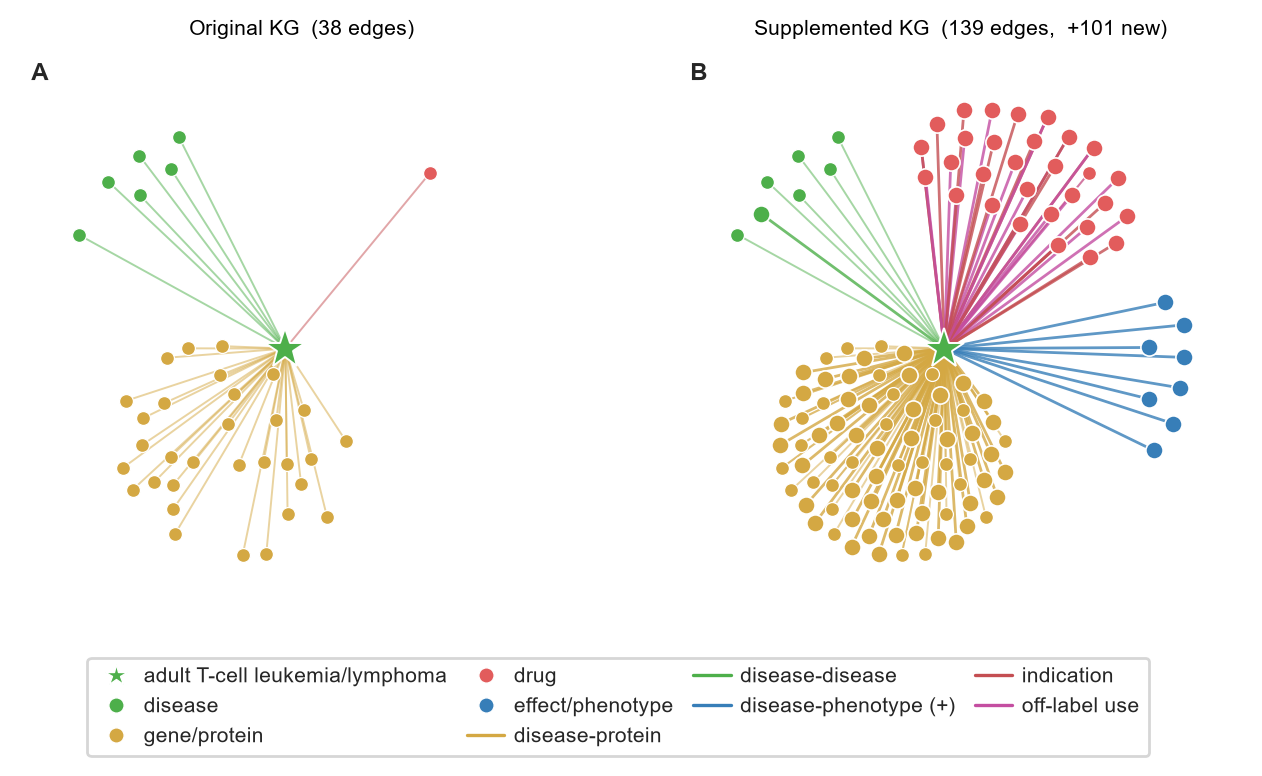

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx
from matplotlib.lines import Line2D
from matplotlib import font_manager as fm
from collections import defaultdict

plt.rcParams['figure.dpi'] = 200
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = [
    fm.FontProperties(fname=r'C:\\Windows\\Fonts\\arial.ttf').get_name(),
    fm.FontProperties(fname=r'C:\\Windows\\Fonts\\FZSTK.TTF').get_name(),
    'SimSun',
    'DejaVu Sans',
]
plt.rcParams['font.size'] = 7.5
plt.rcParams['axes.titlesize'] = 7.5
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['axes.unicode_minus'] = False

center_node = disease_name

cm_to_in = 1 / 2.54
fig_width_cm = 16.5
fig_height_cm = 10.2


type_colors = {
    'gene/protein': '#D4A843',
    'disease': '#4DAF4A',
    'drug': '#E25C5C',
    'effect/phenotype': '#377EB8',
}

relation_colors = {
    'disease_protein': '#D4A843',
    'disease_disease': '#4DAF4A',
    'indication': '#C44E52',
    'off-label use': '#c44ea1',
    'disease_phenotype_positive': '#377EB8',
    'disease_phenotype_negative': '#7EB4D8',
}


def parse_edges(df, center_name):
    result = []
    for _, row in df.iterrows():
        if row['x_name'] == center_name:
            nb, nb_type = row['y_name'], row['y_type']
        else:
            nb, nb_type = row['x_name'], row['x_type']
        result.append({'name': nb, 'type': nb_type, 'relation': row['relation']})
    return result


origin_edge_list = parse_edges(origin, disease_name)
supplement_edge_list = parse_edges(supplement, disease_name)
origin_node_set = {e['name'] for e in origin_edge_list}

# --- 只对补充后的图做一次力导向布局，左图复用其中对应节点的位置 ---
G_supp = nx.Graph()
G_supp.add_node(center_node)
all_supp_nodes = {}
for e in supplement_edge_list:
    all_supp_nodes[e['name']] = e['type']
    G_supp.add_node(e['name'], node_type=e['type'])
    G_supp.add_edge(center_node, e['name'])

by_type_supp = defaultdict(list)
for name, tp in all_supp_nodes.items():
    if name not in by_type_supp[tp]:
        by_type_supp[tp].append(name)
for tp, names in by_type_supp.items():
    for i in range(len(names)):
        for j in range(i + 1, len(names)):
            G_supp.add_edge(names[i], names[j], weight=0.05)

supp_pos = nx.spring_layout(
    G_supp,
    k=1.8 / np.sqrt(len(G_supp)),
    iterations=200,
    seed=42,
    weight='weight',
)

scx, scy = supp_pos[center_node]
for n in supp_pos:
    supp_pos[n] = (supp_pos[n][0] - scx, supp_pos[n][1] - scy)

max_r_supp = max(np.sqrt(x**2 + y**2) for n, (x, y) in supp_pos.items() if n != center_node)
if max_r_supp > 0:
    sc2 = 1.3 / max_r_supp
    for n in supp_pos:
        if n != center_node:
            supp_pos[n] = (supp_pos[n][0] * sc2, supp_pos[n][1] * sc2)

base_pos = {n: supp_pos[n] for n in supp_pos if n == center_node or n in origin_node_set}


# --- 绘图函数 ---
def draw_graph(ax, edge_list, pos, title, subplot_label, highlight_new=False):
    ax.set_aspect('equal')
    ax.axis('off')

    for e in edge_list:
        nb = e['name']
        if nb not in pos:
            continue
        x0, y0 = pos[center_node]
        x1, y1 = pos[nb]
        ec = relation_colors.get(e['relation'], '#aaaaaa')
        is_new = highlight_new and nb not in origin_node_set
        lw = 1.0 if is_new else 0.7
        alpha = 0.8 if is_new else 0.5
        ax.plot(
            [x0, x1],
            [y0, y1],
            color=ec,
            linewidth=lw,
            alpha=alpha,
            zorder=1,
            solid_capstyle='round',
        )

    drawn = set()
    for e in edge_list:
        nb = e['name']
        if nb in drawn or nb not in pos:
            continue
        drawn.add(nb)
        x, y = pos[nb]
        nc = type_colors.get(e['type'], '#888888')
        is_new = highlight_new and nb not in origin_node_set
        ms = 6.2 if is_new else 5.0
        ew = 0.6 if is_new else 0.45
        ax.plot(
            x,
            y,
            'o',
            markersize=ms,
            color=nc,
            markeredgecolor='white',
            markeredgewidth=ew,
            zorder=5,
        )

    ax.plot(
        0,
        0,
        marker='*',
        markersize=15,
        color=type_colors['disease'],
        markeredgecolor='white',
        markeredgewidth=0.7,
        zorder=10,
    )

    ax.text(
        0.02,
        0.98,
        subplot_label,
        transform=ax.transAxes,
        fontsize=8.5,
        fontweight='bold',
        ha='left',
        va='top',
    )
    ax.set_title(title, fontsize=7.5, color='#000', pad=6)


# --- 统一坐标范围 ---
all_positions = list(base_pos.values()) + list(supp_pos.values())
all_xs = [p[0] for p in all_positions]
all_ys = [p[1] for p in all_positions]
margin = 0.3
global_xlim = (min(all_xs) - margin, max(all_xs) + margin)
global_ylim = (min(all_ys) - margin, max(all_ys) + margin)

fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize=(fig_width_cm * cm_to_in, fig_height_cm * cm_to_in),
    facecolor='white',
)

n_new = len(supplement) - len(origin)

draw_graph(ax1, origin_edge_list, base_pos, f'Original KG  ({len(origin)} edges)', 'A')
draw_graph(
    ax2,
    supplement_edge_list,
    supp_pos,
    f'Supplemented KG  ({len(supplement)} edges,  +{n_new} new)',
    'B',
    highlight_new=True,
)

for ax in (ax1, ax2):
    ax.set_xlim(global_xlim)
    ax.set_ylim(global_ylim)

node_handles = [
    Line2D(
        [0],
        [0],
        marker='*',
        color='white',
        markerfacecolor=type_colors['disease'],
        markersize=8,
        markeredgecolor='white',
        markeredgewidth=0.5,
        label='adult T-cell leukemia/lymphoma',
    ),
    Line2D(
        [0],
        [0],
        marker='o',
        color='white',
        markerfacecolor=type_colors['disease'],
        markersize=5.5,
        markeredgecolor='white',
        markeredgewidth=0.5,
        label='disease',
    ),
    Line2D(
        [0],
        [0],
        marker='o',
        color='white',
        markerfacecolor=type_colors['gene/protein'],
        markersize=5.5,
        markeredgecolor='white',
        markeredgewidth=0.5,
        label='gene/protein',
    ),
    Line2D(
        [0],
        [0],
        marker='o',
        color='white',
        markerfacecolor=type_colors['drug'],
        markersize=5.5,
        markeredgecolor='white',
        markeredgewidth=0.5,
        label='drug',
    ),
    Line2D(
        [0],
        [0],
        marker='o',
        color='white',
        markerfacecolor=type_colors['effect/phenotype'],
        markersize=5.5,
        markeredgecolor='white',
        markeredgewidth=0.5,
        label='effect/phenotype',
    ),
]

edge_handles = [
    Line2D([0], [0], color=relation_colors['disease_protein'], linewidth=1.2, label='disease-protein'),
    Line2D([0], [0], color=relation_colors['disease_disease'], linewidth=1.2, label='disease-disease'),
    Line2D([0], [0], color=relation_colors['disease_phenotype_positive'], linewidth=1.2, label='disease-phenotype (+)'),
    Line2D([0], [0], color=relation_colors['indication'], linewidth=1.2, label='indication'),
    Line2D([0], [0], color=relation_colors['off-label use'], linewidth=1.2, label='off-label use'),
]

all_handles = node_handles + edge_handles

fig.legend(
    handles=all_handles,
    loc='lower center',
    ncol=4,
    frameon=True,
    edgecolor='#CCCCCC',
    facecolor='white',
    fontsize=7.5,
    handlelength=1.8,
    handletextpad=0.45,
    columnspacing=0.95,
    bbox_to_anchor=(0.5, 0.01),
    borderpad=0.45,
)

plt.subplots_adjust(bottom=0.20, wspace=0.12, top=0.90, left=0.03, right=0.99)
plt.savefig('supplement_comparison.pdf', bbox_inches='tight', facecolor='white', dpi=600)
plt.savefig(
    'supplement_comparison.tif',
    bbox_inches='tight',
    facecolor='white',
    dpi=300,
    pil_kwargs={'compression': 'tiff_lzw'},
)
# plt.savefig('supplement_comparison.eps', bbox_inches='tight', facecolor='white', dpi=600)
plt.show()